In [1]:
import json
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
INPUT_FILE = "wyniki.json"
THRESHOLD = 0.80

In [3]:
def parse_percentage(val):
    try:
        val_str = str(val)
        return float(val_str.strip('%')) / 100.0

    except ValueError:
        print(f"Warning: Could not parse '{val}', defaulting to 0.0")
        return 0.0

In [4]:
def load_stacked_json(filepath):
    all_data = []
    with open(filepath, 'r') as file:
        content = file.read()

    decoder = json.JSONDecoder()
    idx = 0
    length = len(content)

    while idx < length:
        while idx < length and content[idx].isspace():
            idx += 1
        if idx >= length:
            break

        array_data, idx = decoder.raw_decode(content, idx)
        all_data.extend(array_data)

    return all_data


In [5]:
data = load_stacked_json(INPUT_FILE)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

def optimize_threshold(y_true_bin, y_pred_prob):
    # Calculate precision and recall for all possible thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_true_bin, y_pred_prob)

    # Calculate F1 score for all thresholds
    # Avoid division by zero
    f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls),
                          out=np.zeros_like(precisions), where=(precisions + recalls) != 0)

    # Find the threshold that gives the highest F1 Score
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    best_f1 = f1_scores[optimal_idx]
    best_precision = precisions[optimal_idx]
    best_recall = recalls[optimal_idx]

    print("\n" + "="*50)
    print(" THRESHOLD OPTIMIZATION RESULTS")
    print("="*50)
    print(f"Optimal Threshold: {optimal_threshold:.4f}")
    print(f"Maximized F1-Score: {best_f1 * 100:.2f}%")
    print(f"Resulting Precision: {best_precision * 100:.2f}%")
    print(f"Resulting Recall:    {best_recall * 100:.2f}%")

    # Optional: Plot the curve for your paper
    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precisions[:-1], label="Precision")
    plt.plot(thresholds, recalls[:-1], label="Recall")
    plt.plot(thresholds, f1_scores[:-1], label="F1 Score", linestyle="--")
    plt.axvline(x=optimal_threshold, linestyle=":", label=f"Optimal Threshold ({optimal_threshold:.2f})")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title("Precision-Recall vs. Threshold")
    plt.legend()
    plt.grid(True)
    plt.show()

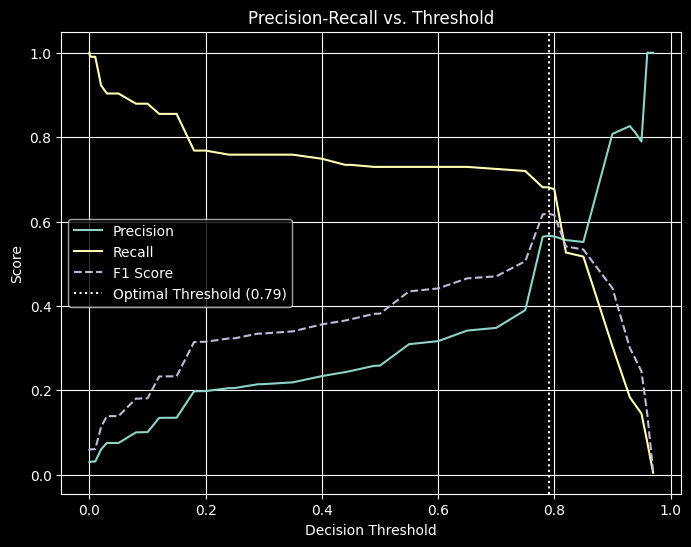

In [16]:
y_true_bin = (y_true_prob >= 0.8).astype(int) # Ground truth binary
optimize_threshold(y_true_bin, y_pred_prob)

In [12]:
y_true_prob = []
y_pred_prob = []
failed_analysis_logs = []

for item in data:
    gt_val = parse_percentage(item.get("Original_exploitability", "0%"))
    y_true_prob.append(gt_val)

    pred_val = parse_percentage(item.get("Exploitability", "0%"))
    y_pred_prob.append(pred_val)

    failed_analysis_logs.append({
        "cve": item.get("Vulnerability"),
        "location": item.get("Location"),
        "gt": gt_val,
        "pred": pred_val,
        "explanation": item.get("Exploitability_explanation", "No explanation provided")
    })

In [13]:
y_true_prob = np.array(y_true_prob)
y_pred_prob = np.array(y_pred_prob)

# 1. BINARY CLASSIFICATION (The Thresholded Baseline)
y_true_bin = (y_true_prob >= THRESHOLD).astype(int)
y_pred_bin = (y_pred_prob >= THRESHOLD).astype(int)

precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()

total_alerts = len(y_true_bin)
not_exploitable_predicted = tn + fn # Total alerts the system flagged as < 50%
noise_reduction = not_exploitable_predicted / total_alerts

# 2. PROBABILISTIC CALIBRATION (The Novelty)
mae = mean_absolute_error(y_true_prob, y_pred_prob)
mse = mean_squared_error(y_true_prob, y_pred_prob)

In [14]:
print("\n" + "="*50)
print(" 1. BINARY REACHABILITY (Fill in Table 1)")
print("="*50)
print(f"Total Alerts Evaluated: {total_alerts}")
print(f"True Positives (TP):  {tp}")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print("-" * 50)
print(f"Precision:       {precision * 100:.2f}%")
print(f"Recall:          {recall * 100:.2f}%")
print(f"F1-Score:        {f1 * 100:.2f}%")
print(f"Noise Reduction: {noise_reduction * 100:.2f}%")

print("\n" + "="*50)
print(" 2. PROBABILISTIC CALIBRATION (Section 4.3)")
print("="*50)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")


 1. BINARY REACHABILITY (Fill in Table 1)
Total Alerts Evaluated: 7018
True Positives (TP):  140
True Negatives (TN):  6703
False Positives (FP): 108
False Negatives (FN): 67
--------------------------------------------------
Precision:       56.45%
Recall:          67.63%
F1-Score:        61.54%
Noise Reduction: 96.47%

 2. PROBABILISTIC CALIBRATION (Section 4.3)
Mean Absolute Error (MAE): 0.1302
Mean Squared Error (MSE): 0.0554


In [17]:
# 3. EXTRACT FAILURES FOR TAXONOMY SECTION
print("\n" + "="*50)
print(" 3. ERROR ANALYSIS EXTRACTION (Section 4.4)")
print("="*50)

fp_list = [log for log in failed_analysis_logs if log['pred'] >= THRESHOLD and log['gt'] < THRESHOLD]
fn_list = [log for log in failed_analysis_logs if log['pred'] < THRESHOLD and log['gt'] >= THRESHOLD]

print(f"Found {len(fp_list)} False Positives and {len(fn_list)} False Negatives.")

print("\n--- Top 3 False Negatives (Critical Failures) ---")
for i, fn_log in enumerate(fn_list[:3]):
    print(f"\n[{i+1}] {fn_log['cve']} in {fn_log['location']}")
    print(f"    System predicted: {fn_log['pred']*100}% | Ground Truth: {fn_log['gt']*100}%")
    print(f"    Explanation: {fn_log['explanation']}")

print("\n--- Top 3 False Positives (Wasted Time) ---")
for i, fp_log in enumerate(fp_list[:3]):
    print(f"\n[{i+1}] {fp_log['cve']} in {fp_log['location']}")
    print(f"    System predicted: {fp_log['pred']*100}% | Ground Truth: {fp_log['gt']*100}%")
    print(f"    Explanation: {fp_log['explanation']}")


 3. ERROR ANALYSIS EXTRACTION (Section 4.4)
Found 108 False Positives and 67 False Negatives.

--- Top 3 False Negatives (Critical Failures) ---

[1] CVE-2025-66507 in github.com/1Panel-dev/1Panel/core:
    System predicted: 5.0% | Ground Truth: 85.0%
    Explanation: Version SAFE. The `Login` struct in `core/app/dto/auth.go` does not contain the `ignoreCaptcha` field. While the frontend uses a variable with this name to manage UI visibility, it is derived from the backend's `needCaptcha` response and is NOT sent to the server. The backend relies solely on server-side `IPTracker` logic. Status: not_confirmed (Fixed version).

[2] CVE-2023-31125 in engine.io:6.4.1
    System predicted: 1.0% | Ground Truth: 80.0%
    Explanation: The vulnerable API (engine.io) is not called in any active code path. Thorough search for explicit calls returned no results. EVIDENCE MANDATE Outcome: status: not_confirmed, probability: 0.01, exploitable: false.

[3] CVE-2025-68470 in react-router:6.6.2
    S

In [18]:
# Assuming y_true_prob and y_pred_prob are your arrays
tolerance = 0.20

# Calculate the absolute difference between prediction and ground truth
differences = np.abs(y_pred_prob - y_true_prob)

# Count how many are within the 20 percentage point tolerance
within_tolerance = np.sum(differences <= tolerance)
total_alerts = len(y_true_prob)

bounded_accuracy = within_tolerance / total_alerts

print(f"Alerts within +/- 20% tolerance: {within_tolerance} / {total_alerts}")
print(f"Bounded Tolerance Accuracy:      {bounded_accuracy * 100:.2f}%")

Alerts within +/- 20% tolerance: 5706 / 7018
Bounded Tolerance Accuracy:      81.31%


In [19]:
from sklearn.metrics import roc_auc_score

print("\n" + "=" * 50)
print(" 4. TRIAGE EFFICACY & PRIORITIZATION (Ranking Metrics)")
print("=" * 50)

# 1. Area Under the ROC Curve (AUROC)
# This measures the model's ability to rank a random True Positive higher than a random True Negative.
try:
    auroc = roc_auc_score(y_true_bin, y_pred_prob)
    print(f"Area Under ROC Curve (AUROC): {auroc:.4f}")
except ValueError:
    print("AUROC: Undefined (Check your dataset, might only have one class present)")

# 2. Sort the dataset descending by predicted probability
# This simulates a security analyst starting at the highest score and working down.
descending_indices = np.argsort(y_pred_prob)[::-1]
y_true_sorted = y_true_bin[descending_indices]
y_pred_prob_sorted = y_pred_prob[descending_indices]

total_actual_threats = np.sum(y_true_bin)
print(f"Total Actual Threats in Dataset: {total_actual_threats}")

# 3. Effort to Find (EtF)
# How many alerts does an engineer have to read before finding the FIRST real threat?
if total_actual_threats > 0:
    first_threat_idx = np.argmax(y_true_sorted)
    # +1 because index is 0-based, but human review count is 1-based
    print(f"Effort to Find (EtF): {first_threat_idx + 1} reviews to find the first actionable vulnerability.\n")


# 4. Precision/Recall at K (P@K, R@K)
def calculate_k_metrics(k):
    if k > len(y_true_sorted):
        k = len(y_true_sorted)

    top_k_actual = y_true_sorted[:k]
    true_positives_in_k = np.sum(top_k_actual)

    p_at_k = true_positives_in_k / k
    r_at_k = true_positives_in_k / total_actual_threats if total_actual_threats > 0 else 0
    return p_at_k, r_at_k


# Define your review budgets (K) here to match your LaTeX table
# Adjust these values based on your total dataset size if needed
k_budgets = [100, 250, 500, 1000]

print("--- Prioritization Performance (Queue Metrics) ---")
print(f"{'Budget (K)':<12} | {'% of Queue':<12} | {'P@K':<10} | {'R@K':<10}")
print("-" * 52)

for k in k_budgets:
    # Skip if K is larger than the total dataset
    if k > total_alerts:
        continue

    p_at_k, r_at_k = calculate_k_metrics(k)
    pct_queue = (k / total_alerts) * 100

    print(f"{k:<12} | {pct_queue:>5.1f}%       | {p_at_k * 100:>5.2f}%   | {r_at_k * 100:>5.2f}%")


 4. TRIAGE EFFICACY & PRIORITIZATION (Ranking Metrics)
Area Under ROC Curve (AUROC): 0.9052
Total Actual Threats in Dataset: 207
Effort to Find (EtF): 1 reviews to find the first actionable vulnerability.

--- Prioritization Performance (Queue Metrics) ---
Budget (K)   | % of Queue   | P@K        | R@K       
----------------------------------------------------
100          |   1.4%       | 72.00%   | 34.78%
250          |   3.6%       | 56.40%   | 68.12%
500          |   7.1%       | 30.20%   | 72.95%
1000         |  14.2%       | 16.90%   | 81.64%


In [20]:
from sklearn.metrics import ndcg_score

print("\n" + "="*50)
print(" 5. NORMALIZED DISCOUNTED CUMULATIVE GAIN (NDCG)")
print("="*50)

# scikit-learn's ndcg_score expects 2D arrays: shape (n_samples, n_labels)
# So we wrap our 1D arrays in an extra set of brackets.
y_true_2d = [y_true_bin]
y_pred_2d = [y_pred_prob]

# Calculate overall NDCG for the entire dataset
overall_ndcg = ndcg_score(y_true_2d, y_pred_2d)
print(f"Overall NDCG: {overall_ndcg:.4f}\n")

# Calculate NDCG at specific review budgets (K)
print("--- NDCG@K Metrics ---")
print(f"{'Budget (K)':<12} | {'NDCG@K':<10}")
print("-" * 25)

for k in k_budgets:
    if k > total_alerts:
        continue

    ndcg_at_k = ndcg_score(y_true_2d, y_pred_2d, k=k)
    print(f"{k:<12} | {ndcg_at_k:.4f}")


 5. NORMALIZED DISCOUNTED CUMULATIVE GAIN (NDCG)
Overall NDCG: 0.8881

--- NDCG@K Metrics ---
Budget (K)   | NDCG@K    
-------------------------
100          | 0.7635
250          | 0.7085
500          | 0.7419
1000         | 0.7856
